In [2]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [3]:
files = ["~/python_decal_fa25/course_assignments/homework10/M13_0001.fits",
         "~/python_decal_fa25/course_assignments/homework10/M13_0002.fits",
         "~/python_decal_fa25/course_assignments/homework10/M13_0003.fits",
         "~/python_decal_fa25/course_assignments/homework10/M13_0004.fits", 
         "~/python_decal_fa25/course_assignments/homework10/M13_0005.fits"]
appended_data = []
for file in files:
    with fits.open(file) as hdul:
        header = hdul[0].header
        data = hdul[0].data
    appended_data.append(data)

In [4]:
appended_data[4]

array([[505, 480, 514, ..., 490, 526, 518],
       [518, 513, 498, ..., 494, 498, 498],
       [526, 520, 509, ..., 492, 489, 529],
       ...,
       [466, 451, 496, ..., 516, 471, 514],
       [532, 511, 489, ..., 498, 503, 500],
       [509, 488, 501, ..., 532, 558, 511]], dtype=uint16)

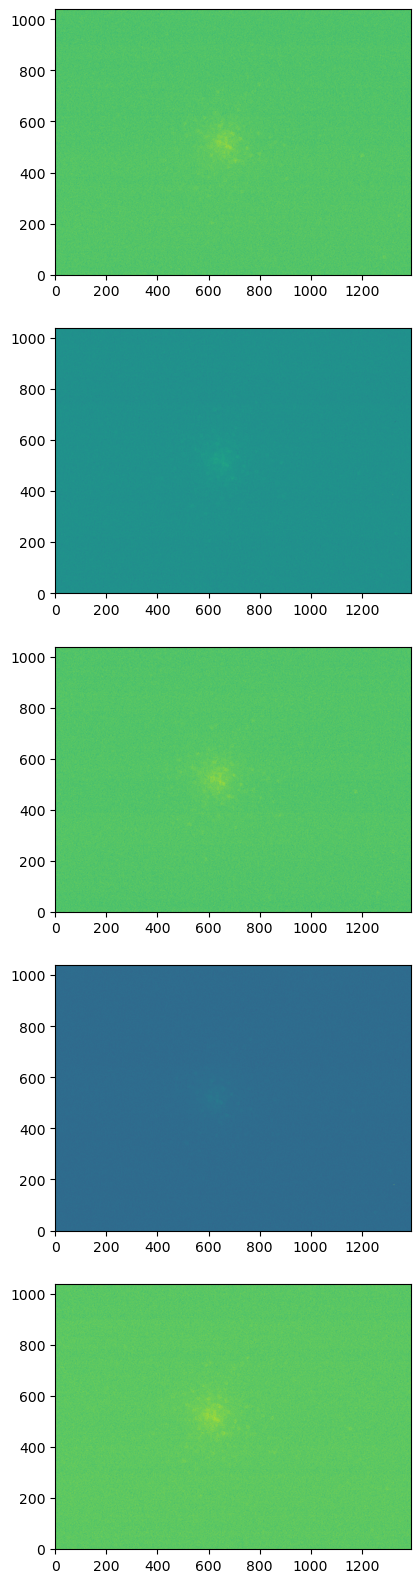

In [5]:
fig, ax = plt.subplots(5,1, figsize=(20,20))

ax[0].imshow(appended_data[0], origin='lower')
ax[1].imshow(appended_data[1], origin='lower')
ax[2].imshow(appended_data[2], origin='lower')
ax[3].imshow(appended_data[3], origin='lower')
ax[4].imshow(appended_data[4], origin='lower')

plt.show()

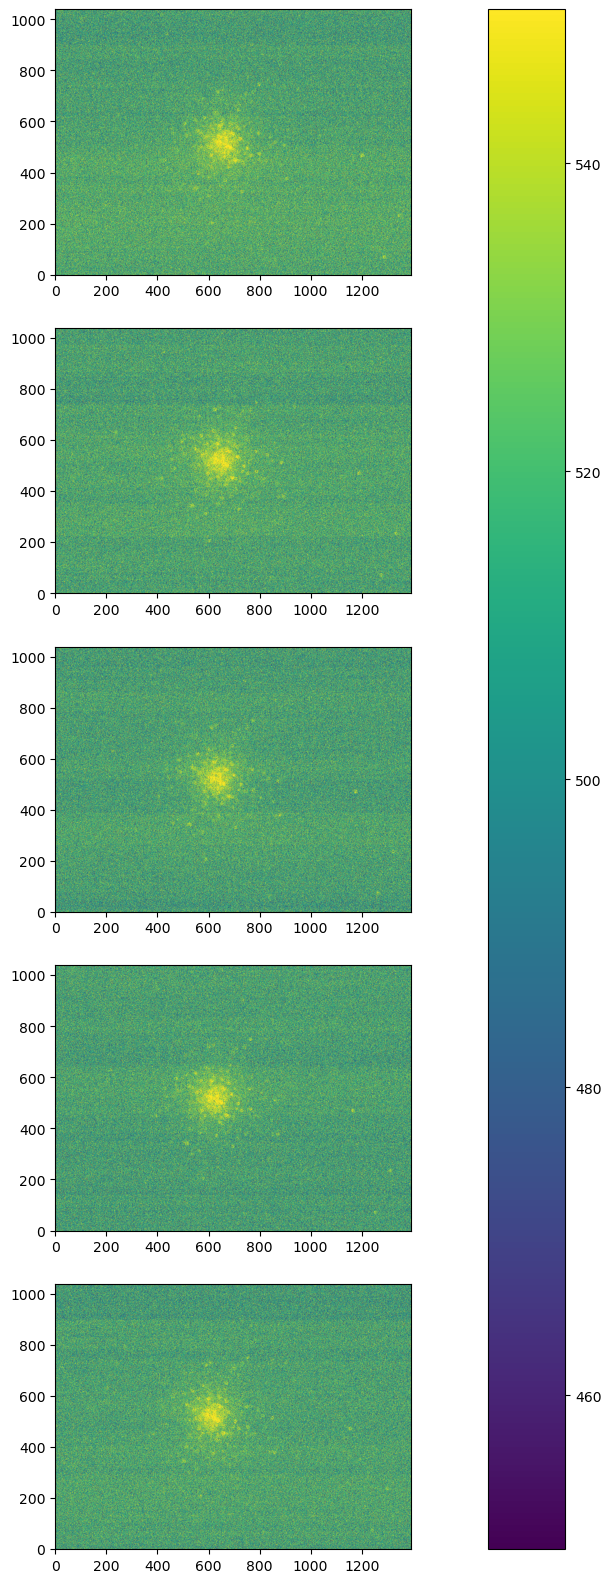

In [6]:
fig, ax = plt.subplots(5,1, figsize=(20,20))

for i in range(5):
    im = ax[i].imshow(appended_data[i], origin='lower', vmin=450, vmax=550)
fig.colorbar(im, ax=ax)
plt.show()

In [7]:
# The object in the image is much clearer and the colors across the subplots are more uniform.

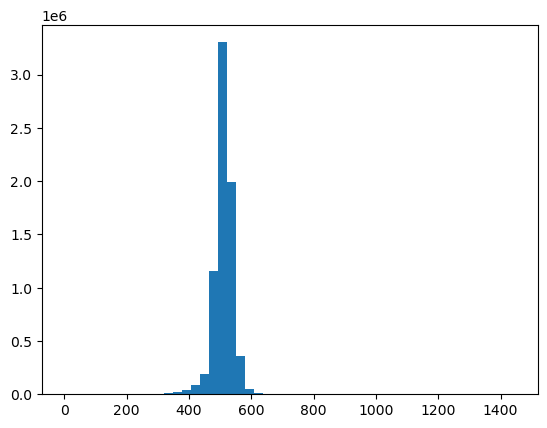

In [8]:
data = np.array(appended_data)

plt.hist(data.ravel(), bins=50)

plt.show()

In [9]:
"""
The array values are on the x axis. The frequeny of the values are on the y axis.

bins=50 means the span of the data is split into 50 bins.

Most of the data is centered around 500 for pixel intensity.

The data is spread about 100 units away from the center.

"""
for i in range(5):
    print(data[i].mean())
    print(np.median(data[i]))

510.4706668600796
512.0
509.7460150033157
511.0
508.0498729000884
510.0
507.90583554376656
509.0
508.7919920148099
510.0


In [18]:
x = np.median(data, axis=0)
low, high = np.percentile(x, [1,99])

In [19]:
np.median(x)

np.float64(510.0)

In [12]:
# It is 510

(array([2.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00,
        2.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 2.00000e+00,
        7.00000e+00, 5.00000e+00, 2.90000e+01, 6.50000e+01, 1.50000e+02,
        3.75000e+02, 1.73700e+03, 1.10920e+04, 6.05660e+04, 2.40828e+05,
        4.16132e+05, 4.17198e+05, 1.96025e+05, 7.55860e+04, 2.03510e+04,
        5.78800e+03, 1.35200e+03, 3.12000e+02, 5.90000e+01, 1.40000e+01]),
 array([  0.  ,  12.46,  24.92,  37.38,  49.84,  62.3 ,  74.76,  87.22,
         99.68, 112.14, 124.6 , 137.06, 149.52, 161.98, 174.44, 186.9 ,
        199.36, 211.82, 224.28, 236.74, 249.2 , 261.66, 274.12, 286.58,
        299.04, 311.5 , 323.96, 336.42, 348.88, 361.

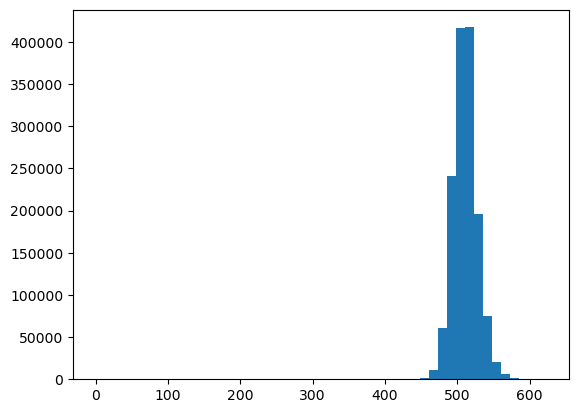

In [13]:
plt.hist(x.ravel(), bins=50)

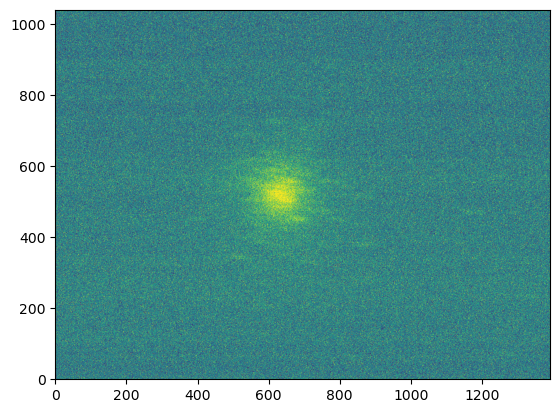

In [22]:
combined_image = plt.imshow(x, origin='lower', vmin=low, vmax=high)

In [21]:
# The image is way clearer than the previous ones.

In [24]:
fits.writeto("combined.fits", x, overwrite=True)

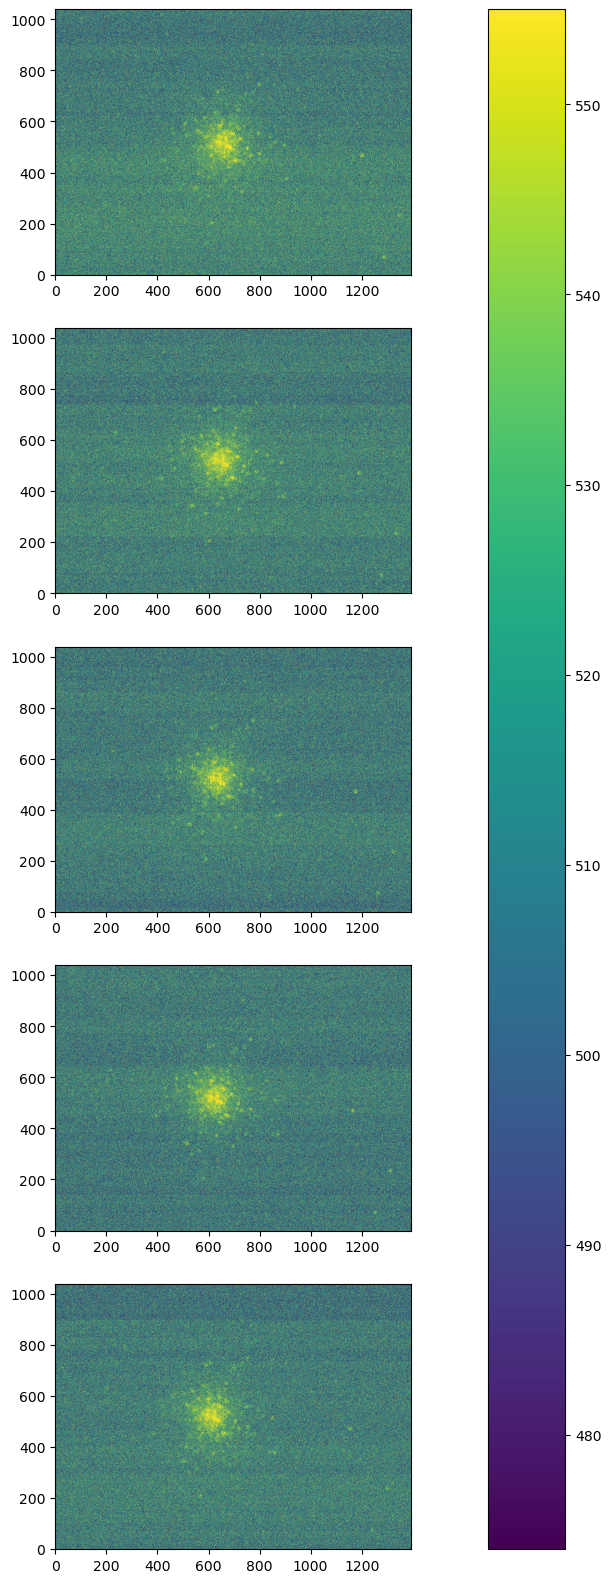

In [25]:
fig, ax = plt.subplots(5,1, figsize=(20,20))

for i in range(5):
    im = ax[i].imshow(appended_data[i], origin='lower', vmin=low, vmax=high)
fig.colorbar(im, ax=ax)
plt.show()